In [ ]:
"""This code cleans and preprocesses a heart disease dataset by handling missing values, detecting/removing outliers, analyzing skewness, and applying log transformation to normalize data, then saves the cleaned dataset to a new CSV file.
It also visualizes data distributions using boxplots and histograms for better insight into the effects of outlier removal and transformation."""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [4]:
print("\nData types and unique values:")
print(df.dtypes)
print(df.nunique())


Data types and unique values:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object
age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64


In [5]:
df = df.fillna(df.median(numeric_only=True))

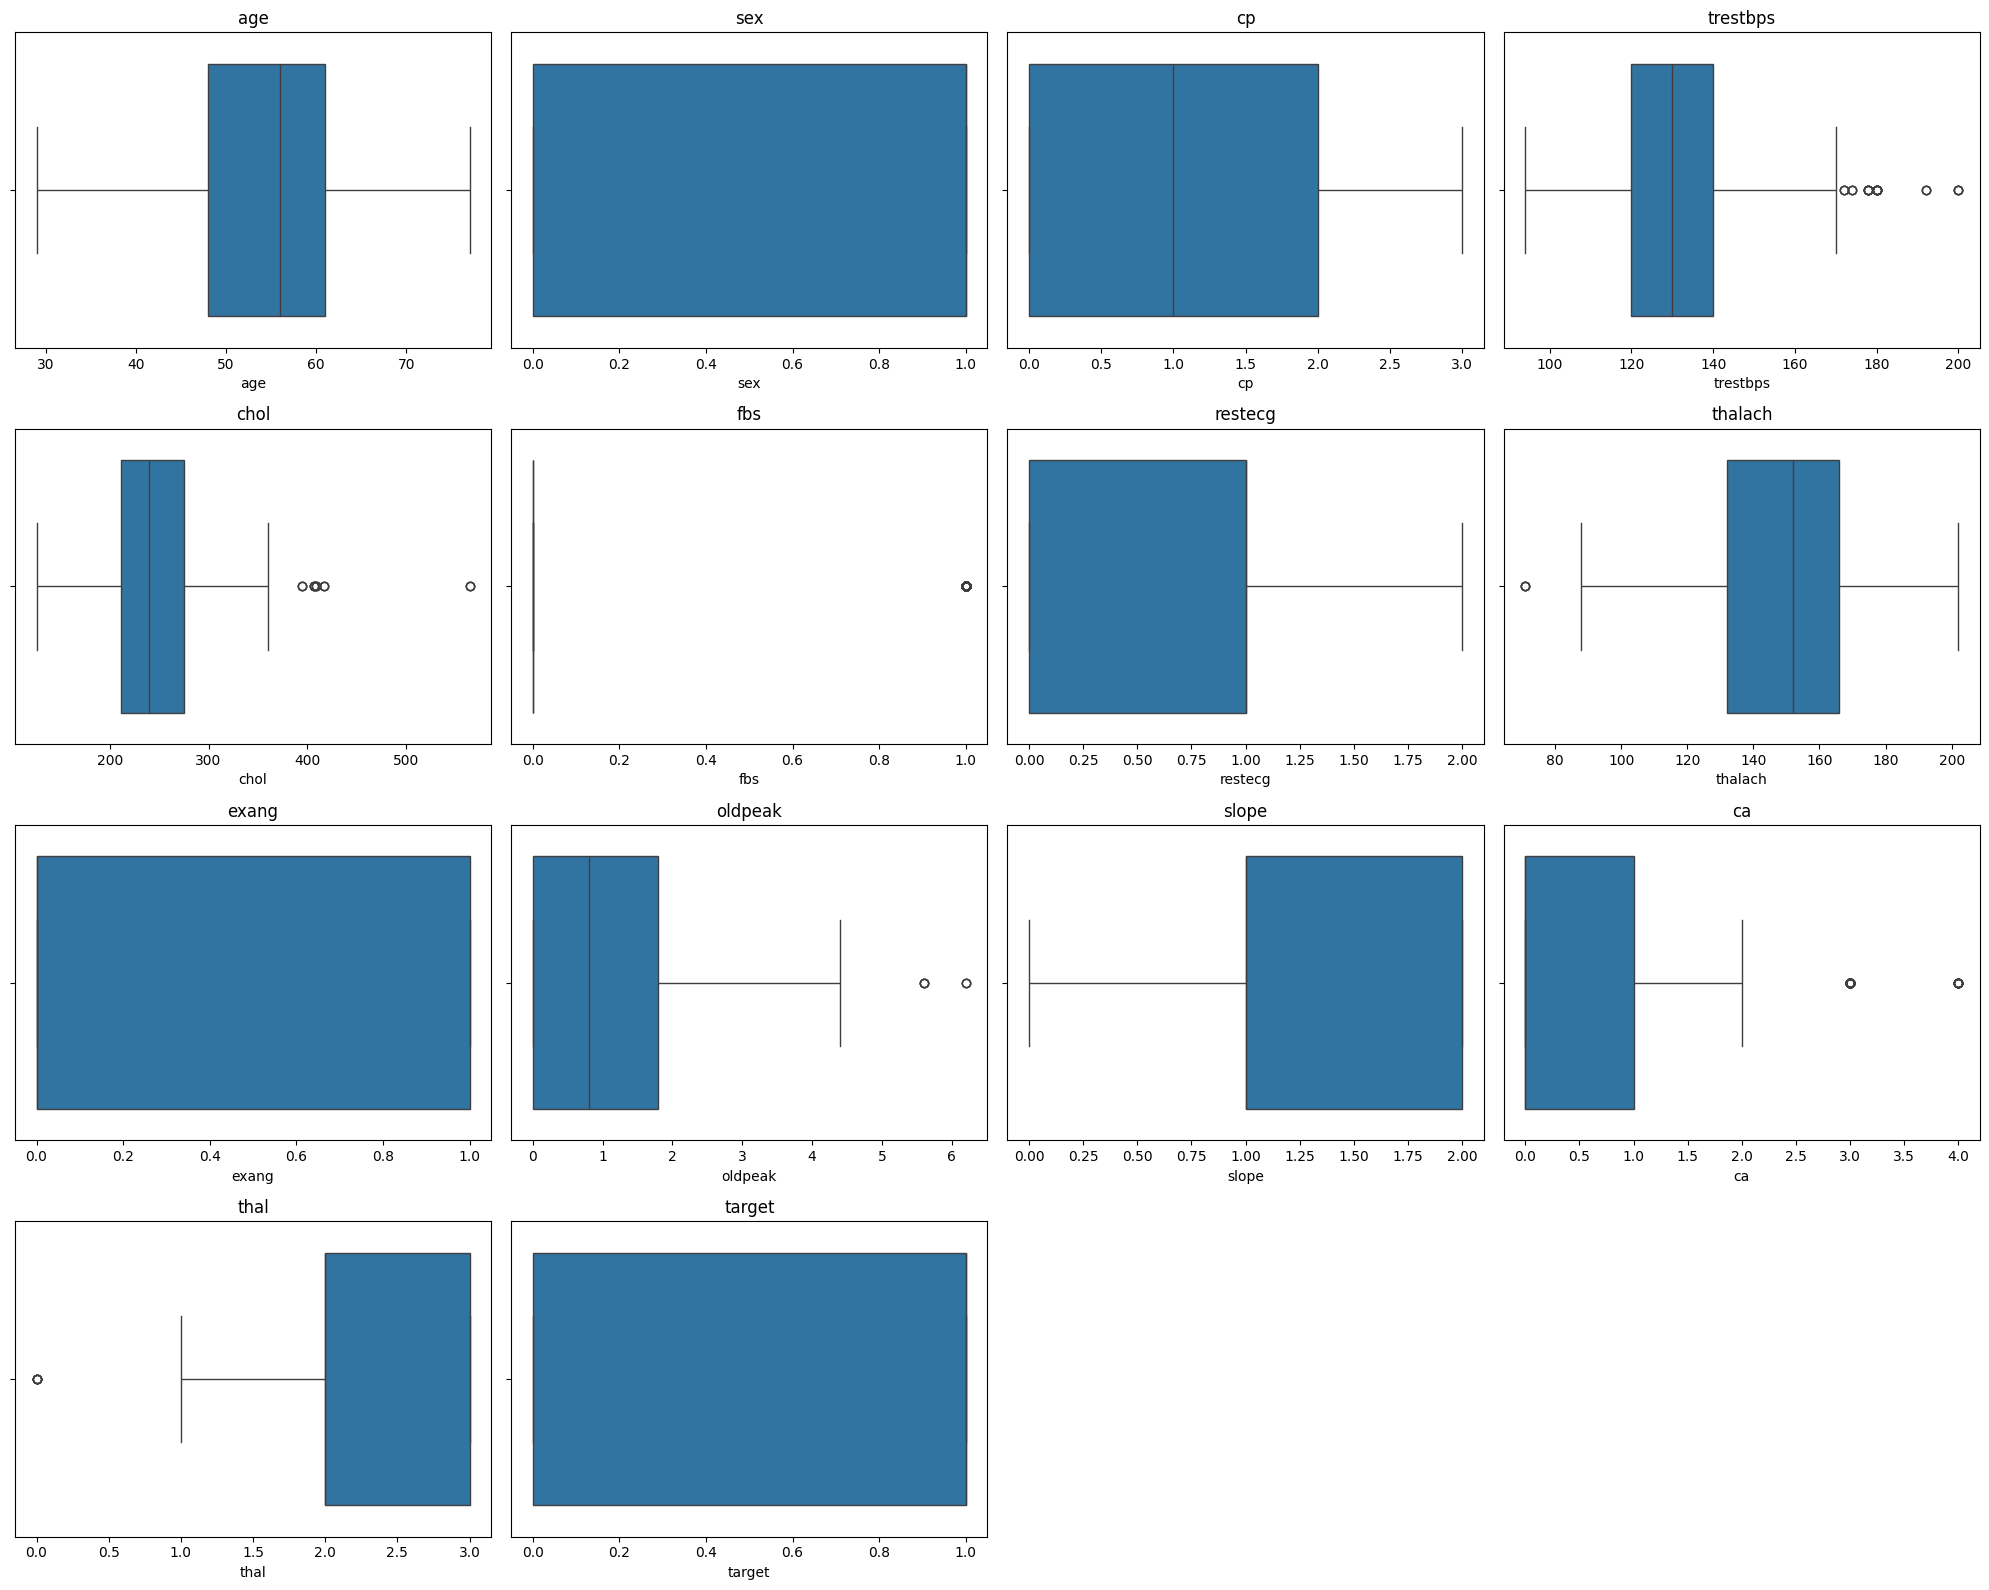

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
# Determine number of rows and columns for subplots
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

# Plot boxplots for each numeric column
plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


In [13]:
# Remove rows where z-score > 3
z_scores = np.abs(stats.zscore(df[numeric_cols]))
df_clean = df[(z_scores < 3).all(axis=1)]
print(f"Original rows: {df.shape[0]}, After removing outliers: {df_clean.shape[0]}")

Original rows: 1025, After removing outliers: 969


In [14]:
# Check skewness before transformation
print("Skewness before log:", df_clean['trestbps'].skew())

Skewness before log: 0.5457202881879579


In [15]:
# Apply log transformation
df_clean['log_trestbps'] = np.log(df_clean['trestbps'])

C:\Users\singh\AppData\Local\Temp\ipykernel_3444\629023530.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['log_trestbps'] = np.log(df_clean['trestbps'])


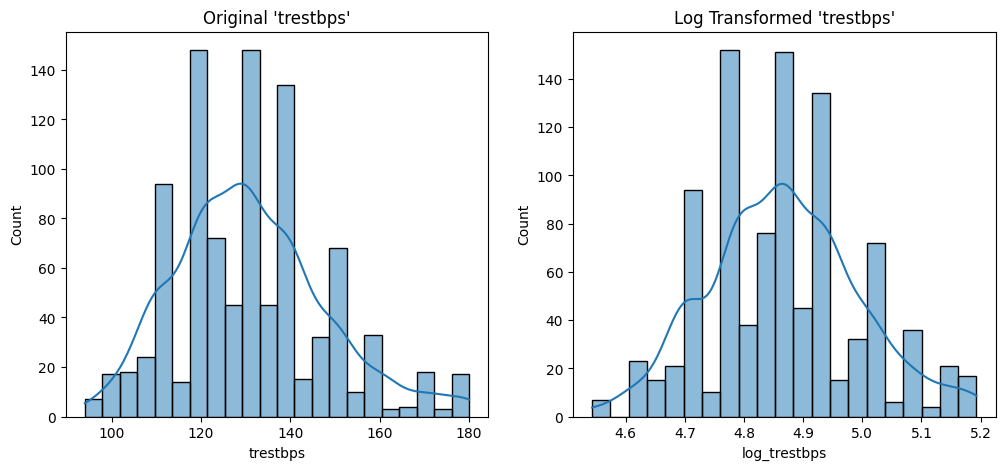

In [17]:
# Plot to visualize transformation
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_clean['trestbps'], kde=True)
plt.title("Original 'trestbps'")

plt.subplot(1, 2, 2)
sns.histplot(df_clean['log_trestbps'], kde=True)
plt.title("Log Transformed 'trestbps'")

plt.show()


In [18]:
print("Skewness after log:", df_clean['log_trestbps'].skew())

Skewness after log: 0.1829428431475184


In [19]:
df_clean.to_csv('heart_cleaned.csv', index=False)
print("Cleaned data saved to 'heart_cleaned.csv'")

Cleaned data saved to 'heart_cleaned.csv'


In [20]:
df_clean.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,log_trestbps
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,4.828314
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,4.941642
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,4.976734
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,4.997212
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,4.927254


In [ ]:
""" Line-by-Line Explanation:
1. import pandas as pd
Imports the pandas library to handle data manipulation and loading of CSV files.

2. import numpy as np
Imports numpy for numerical operations such as array manipulation and mathematical functions.

3. import seaborn as sns
Imports seaborn for advanced data visualization, especially statistical plots.

4. import matplotlib.pyplot as plt
Imports matplotlib.pyplot to create visualizations such as boxplots and histograms.

5. from scipy import stats
Imports stats module from scipy for statistical functions like z-score calculation.

6. df = pd.read_csv('heart.csv')
Loads the heart dataset from a CSV file into a DataFrame named df.

7. df.head()
Displays the first 5 rows of the dataset to get a quick view of the data.

8. print("Missing values in each column:")
Prints a message before showing missing value counts.

9. print(df.isnull().sum())
Prints the count of missing values in each column.

10. print("\nData types and unique values:")
Prints a heading for the next block of output regarding data types and unique values.

11. print(df.dtypes)
Displays the data type of each column.

12. print(df.nunique())
Prints the number of unique values for each column.

13. df = df.fillna(df.median(numeric_only=True))
Fills missing values with the median for each numeric column.

14. numeric_cols = df.select_dtypes(include=[np.number]).columns
Selects only the numeric columns from the DataFrame and stores their names.

15. n_cols = 4
Sets the number of columns for plotting subplots.

16. n_rows = int(np.ceil(len(numeric_cols) / n_cols))
Calculates the number of rows needed for subplotting based on the total number of numeric columns.

17. plt.figure(figsize=(n_cols * 5, n_rows * 4))
Sets the figure size dynamically based on number of rows and columns.

18. for i, col in enumerate(numeric_cols):
Loops over each numeric column with an index.

19. plt.subplot(n_rows, n_cols, i + 1)
Creates a subplot in the specified grid layout.

20. sns.boxplot(x=df[col])
Draws a boxplot for the current numeric column to visualize outliers.

21. plt.title(col)
Sets the title of the subplot to the column name.

22. plt.tight_layout()
Adjusts subplot parameters to avoid overlap between plots.

23. plt.show()
Displays all the generated boxplots.

🎯 Outlier Detection and Removal
24. z_scores = np.abs(stats.zscore(df[numeric_cols]))
Calculates absolute z-scores for each numeric column to detect outliers.

25. df_clean = df[(z_scores < 3).all(axis=1)]
Keeps only rows where all z-scores are less than 3 (removes outliers).

26. print(f"Original rows: {df.shape[0]}, After removing outliers: {df_clean.shape[0]}")
Prints the number of rows before and after outlier removal.

📈 Skewness and Transformation
27. print("Skewness before log:", df_clean['trestbps'].skew())
Prints the skewness of the 'trestbps' (resting blood pressure) column before transformation.

28. df_clean['log_trestbps'] = np.log(df_clean['trestbps'])
Applies a logarithmic transformation to reduce skewness in the 'trestbps' column.

📊 Visualizing Before and After Transformation
29. plt.figure(figsize=(12, 5))
Creates a wide figure for side-by-side histogram plots.

30. plt.subplot(1, 2, 1)
Creates the first subplot.

31. sns.histplot(df_clean['trestbps'], kde=True)
Plots a histogram with a KDE (smoothed line) of the original 'trestbps'.

32. plt.title("Original 'trestbps'")
Titles the first plot.

33. plt.subplot(1, 2, 2)
Creates the second subplot.

34. sns.histplot(df_clean['log_trestbps'], kde=True)
Plots histogram and KDE of log-transformed 'trestbps'.

35. plt.title("Log Transformed 'trestbps'")
Titles the second plot.

36. plt.show()
Displays the histograms.

🔄 After Transformation
37. print("Skewness after log:", df_clean['log_trestbps'].skew())
Prints the skewness after log transformation to show improvement.

💾 Save Cleaned Data
38. df_clean.to_csv('heart_cleaned.csv', index=False)
Saves the cleaned dataset to a new CSV file without row indices.

39. print("Cleaned data saved to 'heart_cleaned.csv'")
Confirms that the cleaned data was saved.

40. df_clean.head()
Displays the first few rows of the cleaned dataset.

"""